In [28]:
import seaborn as sns

# old

In [14]:
import scanpy as sc
import scanpy.external as sce

def load_data():
    # Loading example datasets.
    # For real analysis, replace this with reading actual datasets
    adata_pbmc3k = sc.datasets.pbmc3k_processed()  # Processed PBMC 3k dataset
    adata_pbmc68k = sc.datasets.pbmc68k_reduced()  # Reduced PBMC 68k dataset

    # Add batch information for illustrative purposes.
    adata_pbmc3k.obs['batch'] = 'batch1'
    adata_pbmc68k.obs['batch'] = 'batch2'

    # Concatenate the data together for harmony batch correction
    adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')

    return adata

def batch_correct_data(adata):
    # Ensure you have normalized and logged the data before this step, if needed
    sc.pp.log1p(adata)  # if not logged
    sc.pp.scale(adata, max_value=10)  # scaling by maximum value to mitigate extreme values impact

    # Using Harmony for batch correction
    sce.pp.harmony_integrate(adata, key='batch', adjusted_basis='X_pca_harmony')

    return adata

def visualize_results(adata):
    sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=False)
    sc.pp.neighbors(adata, use_rep='X_pca_harmony')  # Using harmony-adjusted PCA
    sc.tl.umap(adata)
    sc.pl.umap(adata, color='batch', title='UMAP after Harmony Integration', save='_harmony_batch_correction.png')

def main():
    adata = load_data()
    adata_corrected = batch_correct_data(adata)
    visualize_results(adata_corrected)

if __name__ == "__main__":
    main()

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_69469/1516550458.py:15: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)
2025-01-20 13:52:43,650 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-20 13:52:46,283 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-20 13:52:46,436 - harmonypy - INFO - Iteration 1 of 10
2025-01-20 13:52:47,988 - harmonypy - INFO - Iteration 2 of 10
2025-01-20 13:52:49,236 - harmonypy - INFO - Iteration 3 of 10
2025-01-20 13:52:50,073 - harmonypy - INFO - Iteration 4 of 10
2025-01-20 13:52:50,603 

ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

### this section has no nan value, but negative values, then log1p has nan values

In [28]:
adata_pbmc3k = sc.datasets.pbmc3k_processed()  # Processed PBMC 3k dataset
adata_pbmc68k = sc.datasets.pbmc68k_reduced()  # Reduced PBMC 68k dataset

# Add batch information for illustrative purposes.
adata_pbmc3k.obs['batch'] = 'batch1'
adata_pbmc68k.obs['batch'] = 'batch2'

# Concatenate the data together for harmony batch correction
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_69469/2860391645.py:9: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')


In [29]:
np.isnan(adata.X).sum()

0

<Axes: >

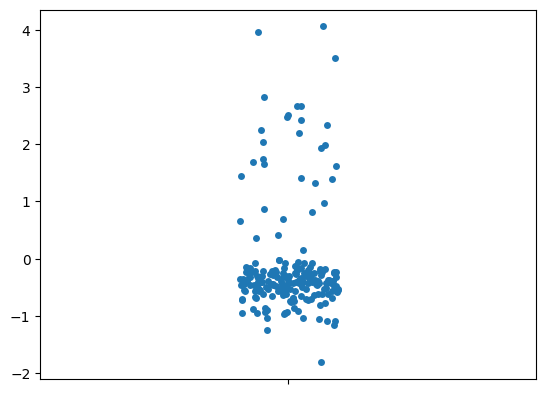

In [32]:
sns.stripplot(adata.X[0])

### problems occur with log1p

In [33]:
sc.pp.log1p(adata)
np.isnan(adata.X).sum()

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


12097

# new: try 3

In [2]:
import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Simulate data load:
# adata_pbmc3k = sc.datasets.pbmc3k()
# adata_pbmc68k = sc.datasets.pbmc68k()
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
sc.pp.log1p(adata_pbmc3k)

sc.pp.normalize_total(adata_pbmc68k, target_sum=1e4)
sc.pp.log1p(adata_pbmc68k)
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized latent representation
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_69469/2909394875.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(a

Training:   0%|          | 0/400 [00:00<?, ?it/s]

ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)

### loaded data have no nan values

In [38]:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.

In [9]:
np.isnan(adata_pbmc3k.X).sum()

0

In [10]:
np.isnan(adata_pbmc68k.X).sum()

0

### normalize_total creates no nan but negative values, leading to nan output of log1p.

In [11]:
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
np.isnan(adata_pbmc3k.X).sum()

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))


0

In [12]:
adata_pbmc3k.X

array([[  31.518042 ,   51.61644  ,    8.579724 , ...,   18.062927 ,
          38.434055 ,   97.64121  ],
       [  28.898796 ,   50.186924 ,    7.3807707, ...,   35.93714  ,
          42.17281  ,   80.354256 ],
       [-257.38486  , -201.51965  ,  -39.286816 , ..., -108.34969  ,
        -116.69532  ,  941.7498   ],
       ...,
       [  32.24917  ,   39.003693 ,    7.2252083, ...,    7.964478 ,
          25.081854 , -317.9137   ],
       [ -47.838997 ,  -56.888905 ,  -11.059235 , ...,   -1.4874197,
         -33.985767 , -121.178535 ],
       [  40.209915 ,   30.548422 ,    6.350388 , ...,    9.447393 ,
          15.6998625,   56.779724 ]], dtype=float32)

<Axes: >

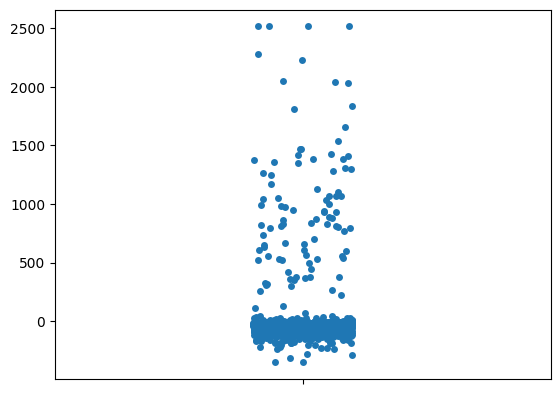

In [20]:
sns.stripplot(adata_pbmc3k.X[-2])

### after log1p, many nan values occur.

In [22]:
sc.pp.log1p(adata_pbmc3k)
np.isnan(adata_pbmc3k.X).sum()

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_simple.py:383: RuntimeWarning: invalid value encountered in log1p
  np.log1p(X, out=X)


2042302

# Analysis

### notes: original report says this problem can be resolved by [github issue](https://github.com/scverse/scanpy/issues/2163). Indeed it can't! The consequence of our problem, original report and this issue is similar: adata.X has nan values. But our and original report is caused by negative values of data.X (or after normalization) + log1p, and the github issue is caused by constant data.X column + pp.scale with 0 std as denominator. see [github discussion](https://github.com/scverse/scanpy/issues/2163#issuecomment-2199782706) for details. Constant gene, if all 0, has not been observed, and has no differentiation for observations even if not all 0. 

### Our (and original) report are caused by negative values in data.X, rather than constant genes! Github issue does no help.

### solutions in biomamia to our cases:
#### 1. noted that our loaded datasets are already processed (including normalization, log1p, etc). It requires no preprocessing anymore. It makes no sense not to load dataset at the first step, or not to mention whether this dataset has been pre-processed or not.
#### 2. scanpy warning gives some clues: "RuntimeWarning: invalid value encountered in log1p np.log1p(X, out=X)". This is exactly where nan values come. Biomania can use this message (and by accessing data matrix) to debug itself, e.g. ignoring lop1p step.
#### 3. to test whether preprocessing steps are needed - all preprocessing steps are to achieve some criteria, such as normalizing values into some ranges. Before each preprocessing step, biomania can check whether corresponding criteria is achieved. If yes, then no preprocessing; if not, then preprocessing.
* considering that single-cell RNAseq analysis can be formalized into some fixed steps (see [single-cell best pracitice](https://www.sc-best-practices.org/preamble.html)), we can formalize preprocessing as a multi-step module in biomania, and let biomania preprocess each input data. Each step is conducted only when the criteria is not met by data.

# sol 1.1: use original data

## old
* solution: by accessing error, we see that necessary pca step is not conducted
* solution: by accessing document, we see "As Harmony works by adjusting the principal components, this function should be run after performing PCA but before computing the neighbor graph, as illustrated in the example below." and corresponding examples.

In [14]:
import scanpy as sc
import scanpy.external as sce

def load_data():
    # Loading example datasets.
    # For real analysis, replace this with reading actual datasets
    adata_pbmc3k = sc.datasets.pbmc3k()
    adata_paul15 = sc.datasets.paul15()

    # Add batch information for illustrative purposes.
    adata_pbmc3k.obs['batch'] = 'batch1'
    adata_paul15.obs['batch'] = 'batch2'

    # Concatenate the data together for harmony batch correction
    adata = adata_pbmc3k.concatenate(adata_paul15, batch_key='batch')

    return adata

def batch_correct_data(adata):
    # Ensure you have normalized and logged the data before this step, if needed
    sc.pp.log1p(adata)  # if not logged
    sc.pp.scale(adata, max_value=10)  # scaling by maximum value to mitigate extreme values impact

    # Using Harmony for batch correction
    sce.pp.harmony_integrate(adata, key='batch', adjusted_basis='X_pca_harmony')

    return adata

def visualize_results(adata):
    sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=False)
    sc.pp.neighbors(adata, use_rep='X_pca_harmony')  # Using harmony-adjusted PCA
    sc.tl.umap(adata)
    sc.pl.umap(adata, color='batch', title='UMAP after Harmony Integration', save='_harmony_batch_correction.png')

def main():
    adata = load_data()
    adata_corrected = batch_correct_data(adata)
    visualize_results(adata_corrected)

if __name__ == "__main__":
    main()

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/3610424881.py:15: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_paul15, batch_key='batch')
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


KeyError: 'X_pca'

## new
* it works!

In [43]:
# note that pbmc68k proposed by gpt4 is not existing. this problem can be resolved by accessing scanpy documents.
adata_pbmc3k = sc.datasets.pbmc3k()
adata_paul15 = sc.datasets.paul15()

In [47]:
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)

In [52]:
sc.pp.log1p(adata_pbmc3k)

In [53]:
sc.pp.normalize_total(adata_paul15, target_sum=1e4)

In [54]:
sc.pp.log1p(adata_paul15)

In [55]:
adata = adata_pbmc3k.concatenate(adata_paul15, batch_key="batch", batch_categories=["pbmc3k", "paul15"])

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_69469/1115215188.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_paul15, batch_key="batch", batch_categories=["pbmc3k", "paul15"])


In [56]:
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator=='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using

Training:   0%|          | 0/400 [00:00<?, ?it/s]

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/module/_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/module/_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/module/_vae.py:569: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs[MODULE_KEYS.PX_KEY].log_prob(x).sum(-1)
`Trainer.fit` stopped: `max_epochs=400` reached.


/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scipy/sparse/_index.py:197: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_69469/2283638865.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


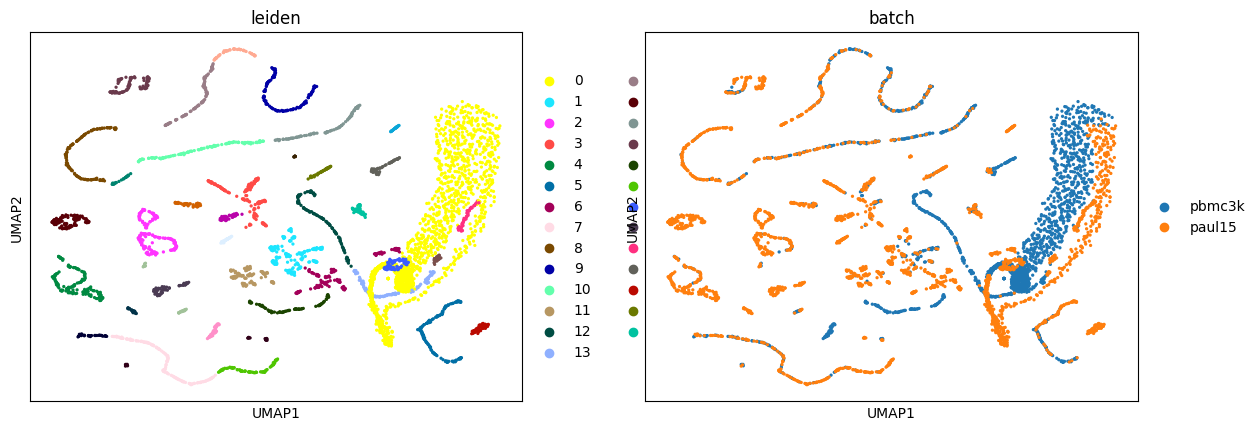

In [57]:
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

# sol 1.2: use preprocessed data (without further preprocessing)

## old
* it works!

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/2819280154.py:15: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')
2025-01-20 15:14:03,489 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-20 15:14:05,868 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-20 15:14:05,924 - harmonypy - INFO - Iteration 1 of 10
2025-01-20 15:14:06,403 - harmonypy - INFO - Iteration 2 of 10
2025-01-20 15:14:06,790 - harmonypy - INFO - Iteration 3 of 10
2025-01-20 15:14:07,221 - harmonypy - INFO - Iteration 4 of 10
2025-01-20 15:14:07,692 - harmonypy - INFO - Iteration 5 of 10
2025-01-20 15:14:08,065 - harmonypy - INFO - Iteration 6 of 10
2025-01-20 15:14:08,334 - harmonypy - INFO - Iteration 7 of 10

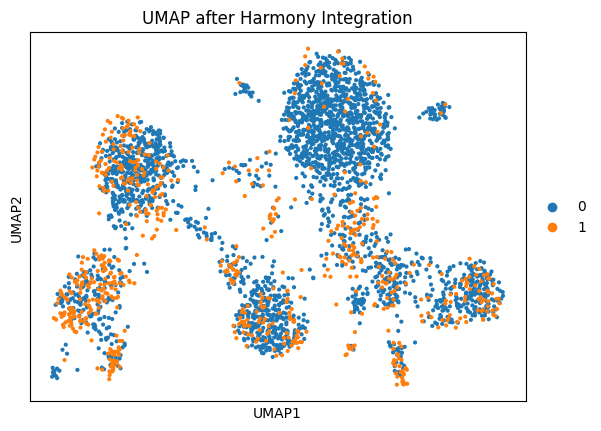

In [15]:
import scanpy as sc
import scanpy.external as sce

def load_data():
    # Loading example datasets.
    # For real analysis, replace this with reading actual datasets
    adata_pbmc3k = sc.datasets.pbmc3k_processed()  # Processed PBMC 3k dataset
    adata_pbmc68k = sc.datasets.pbmc68k_reduced()  # Reduced PBMC 68k dataset

    # Add batch information for illustrative purposes.
    adata_pbmc3k.obs['batch'] = 'batch1'
    adata_pbmc68k.obs['batch'] = 'batch2'

    # Concatenate the data together for harmony batch correction
    adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')

    return adata

def batch_correct_data(adata):
    # Ensure you have normalized and logged the data before this step, if needed
    # sc.pp.log1p(adata)  # if not logged
    # sc.pp.scale(adata, max_value=10)  # scaling by maximum value to mitigate extreme values impact

    # Using Harmony for batch correction
    sce.pp.harmony_integrate(adata, key='batch', adjusted_basis='X_pca_harmony')

    return adata

def visualize_results(adata):
    sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=False)
    sc.pp.neighbors(adata, use_rep='X_pca_harmony')  # Using harmony-adjusted PCA
    sc.tl.umap(adata)
    sc.pl.umap(adata, color='batch', title='UMAP after Harmony Integration', save='_harmony_batch_correction.png')

def main():
    adata = load_data()
    adata_corrected = batch_correct_data(adata)
    visualize_results(adata_corrected)

if __name__ == "__main__":
    main()

## new

In [4]:
import scanpy as sc
import scvi
import numpy as np

In [2]:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/1260841834.py:3: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])


### here maybe the problem. adata counts needs unnormalized count data (all positive). This problem can be resolved by accessing warning of scvi, or providing this warning to users.

### in scvi document: "Unless otherwise specified, scvi-tools models require the raw counts (not log library size normalized). scvi-tools models will run for non-negative real-valued data, ..."

In [7]:
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [8]:
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/train/_trainrunner.py:69: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator=='mps' in train function.In future releases it will become default for mps supported machines.
  accelerator, lightning_devices, device = parse_device_args(
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/lightning/pytorch/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.
/opt/anaconda3/envs/bioma/lib/python3.11/site-

Training:   0%|          | 0/400 [00:00<?, ?it/s]

ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)

# sol 2: ignoring log1p according to warnings

## old
* it works!

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/2982540918.py:15: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')
2025-01-20 15:21:57,526 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-20 15:21:59,652 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-20 15:21:59,683 - harmonypy - INFO - Iteration 1 of 10
2025-01-20 15:22:00,085 - harmonypy - INFO - Iteration 2 of 10
2025-01-20 15:22:00,758 - harmonypy - INFO - Iteration 3 of 10
2025-01-20 15:22:01,164 - harmonypy - INFO - Iteration 4 of 10
2025-01-20 15:22:01,634 - harmonypy - INFO - Iteration 5 of 10
2025-01-20 15:22:02,117 - harmonypy - INFO - Iteration 6 of 10
2025-01-20 15:22:02,458 - harmonypy - INFO - Iteration 7 of 10

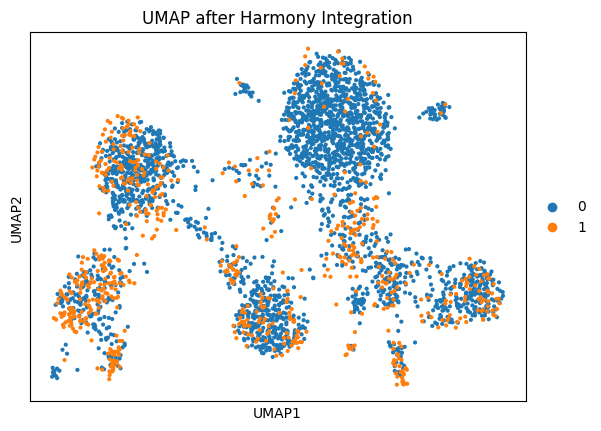

In [16]:
import scanpy as sc
import scanpy.external as sce

def load_data():
    # Loading example datasets.
    # For real analysis, replace this with reading actual datasets
    adata_pbmc3k = sc.datasets.pbmc3k_processed()  # Processed PBMC 3k dataset
    adata_pbmc68k = sc.datasets.pbmc68k_reduced()  # Reduced PBMC 68k dataset

    # Add batch information for illustrative purposes.
    adata_pbmc3k.obs['batch'] = 'batch1'
    adata_pbmc68k.obs['batch'] = 'batch2'

    # Concatenate the data together for harmony batch correction
    adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')

    return adata

def batch_correct_data(adata):
    # Ensure you have normalized and logged the data before this step, if needed
    # sc.pp.log1p(adata)  # if not logged
    sc.pp.scale(adata, max_value=10)  # scaling by maximum value to mitigate extreme values impact

    # Using Harmony for batch correction
    sce.pp.harmony_integrate(adata, key='batch', adjusted_basis='X_pca_harmony')

    return adata

def visualize_results(adata):
    sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=False)
    sc.pp.neighbors(adata, use_rep='X_pca_harmony')  # Using harmony-adjusted PCA
    sc.tl.umap(adata)
    sc.pl.umap(adata, color='batch', title='UMAP after Harmony Integration', save='_harmony_batch_correction.png')

def main():
    adata = load_data()
    adata_corrected = batch_correct_data(adata)
    visualize_results(adata_corrected)

if __name__ == "__main__":
    main()

## new
* same problems as above, scvi needs original counts

In [17]:
import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Simulate data load:
# adata_pbmc3k = sc.datasets.pbmc3k()
# adata_pbmc68k = sc.datasets.pbmc68k()
sc.pp.normalize_total(adata_pbmc3k, target_sum=1e4)
# sc.pp.log1p(adata_pbmc3k)

sc.pp.normalize_total(adata_pbmc68k, target_sum=1e4)
# sc.pp.log1p(adata_pbmc68k)
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.X.copy()  # Store the count data
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized latent representation
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_normalization.py:234: UserWarning: Some cells have zero counts
  warn(UserWarning("Some cells have zero counts"))
/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/4122285877.py:16: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:63: UserWarning: adata.layers[counts] does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scvi/model/_scvi.py:159: UserWarning: This dataset has some empty cells, this might fail inference.Data

Training:   0%|          | 0/400 [00:00<?, ?it/s]

ValueError: Expected parameter loc (Tensor of shape (128, 10)) of distribution Normal(loc: torch.Size([128, 10]), scale: torch.Size([128, 10])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        ...,
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan],
        [nan, nan, nan,  ..., nan, nan, nan]], grad_fn=<AddmmBackward0>)

## new: try 1
* simply using "raw.X" doesn't work

In [25]:
import scanpy as sc
import scvi
import numpy as np
# Normally, you would load datasets from files or from Scanpy's dataset functions:
adata_pbmc3k = sc.datasets.pbmc3k_processed()    # Adjust this line as needed.
adata_pbmc68k = sc.datasets.pbmc68k_reduced()   # Adjust this line as needed.
# Concatenate the datasets for integration.
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])

# Prepare data for scVI, defining the batch as categorical
adata.layers["counts"] = adata.raw.X.copy()  # Store the count data
scvi.model.SCVI.setup_anndata(adata, layer="counts", batch_key="batch")
# Initialize and train the model
scvi_model = scvi.model.SCVI(adata)
scvi_model.train()

# Get the harmonized latent representation
latent = scvi_model.get_latent_representation()

# Update AnnData object with the corrected embedding
adata.obsm["X_scVI"] = latent
sc.pp.neighbors(adata, use_rep="X_scVI")
sc.tl.umap(adata)
sc.tl.leiden(adata)
sc.pl.umap(adata, color=["leiden", "batch"])

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/1195247523.py:8: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key="batch", batch_categories=["pbmc3k", "pbmc68k"])


ValueError: Value passed for key 'counts' is of incorrect shape. Values of layers must match dimensions ('obs', 'var') of parent. Value had shape (3338, 764) while it should have had (3338, 208).

# sol 3: test whether certain criteria met

## old
* it works!

In [26]:
import scanpy as sc
import scanpy.external as sce

# Loading example datasets.
# For real analysis, replace this with reading actual datasets
adata_pbmc3k = sc.datasets.pbmc3k_processed()  # Processed PBMC 3k dataset
adata_pbmc68k = sc.datasets.pbmc68k_reduced()  # Reduced PBMC 68k dataset

# Add batch information for illustrative purposes.
adata_pbmc3k.obs['batch'] = 'batch1'
adata_pbmc68k.obs['batch'] = 'batch2'

# Concatenate the data together for harmony batch correction
adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')

/var/folders/_j/jhp4k00j0vx40wdvn_jv_jr40000gn/T/ipykernel_70413/804781070.py:14: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata = adata_pbmc3k.concatenate(adata_pbmc68k, batch_key='batch')


### before harmony_integrate(), two preprocessing steps are required by original codes: log1p and scale. now let's see if we can test criteria of them

### criteria for log1p: data is all > 0, highly skewed and long-tailed (gpt4o-poe), need log1p to make data normally distributed
### result: some samples < 0, slightly skewed and long-tailed. cannot apply log1p. negative values actually implies data may have been pre-processed.

<Axes: >

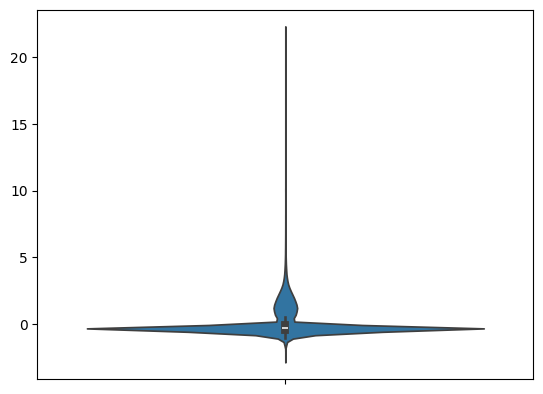

In [29]:
sns.violinplot(adata.X.flatten())

In [31]:
adata.X.min()

-2.756272

### criteria for scale: data has 0 mean and 1 std
* gpt4o-poe: standardize gene expression values by ensuring that each gene has a mean of 0 and a variance of 1 across cells. Scaling is generally applied after normalization and log-transformation and is an important preprocessing step for many downstream analyses.
  
### result: from following results, we see that adata.X has mean close to 0 and std close to 1, thus no need for scale().

In [32]:
adata.X.mean()

-0.0010648408

In [33]:
adata.X.std()

0.9913536

### After removing two preprocessing

2025-01-20 16:33:01,570 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-01-20 16:33:03,686 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-01-20 16:33:03,723 - harmonypy - INFO - Iteration 1 of 10
2025-01-20 16:33:04,460 - harmonypy - INFO - Iteration 2 of 10
2025-01-20 16:33:04,795 - harmonypy - INFO - Iteration 3 of 10
2025-01-20 16:33:05,153 - harmonypy - INFO - Iteration 4 of 10
2025-01-20 16:33:05,550 - harmonypy - INFO - Iteration 5 of 10
2025-01-20 16:33:05,878 - harmonypy - INFO - Iteration 6 of 10
2025-01-20 16:33:06,182 - harmonypy - INFO - Iteration 7 of 10
2025-01-20 16:33:06,385 - harmonypy - INFO - Iteration 8 of 10
2025-01-20 16:33:06,596 - harmonypy - INFO - Iteration 9 of 10
2025-01-20 16:33:06,779 - harmonypy - INFO - Iteration 10 of 10
2025-01-20 16:33:06,951 - harmonypy - INFO - Stopped before convergence
/opt/anaconda3/envs/bioma/lib/python3.11/site-packages/scanpy/preprocessing/_pca.py:374: FutureWarning: Argument `us

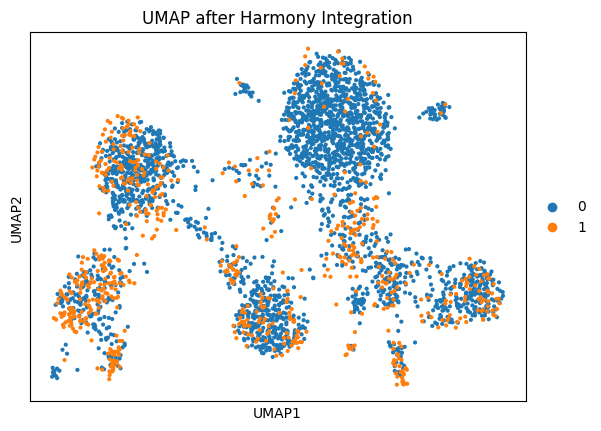

In [34]:
# Ensure you have normalized and logged the data before this step, if needed
# sc.pp.log1p(adata)  # if not logged
# sc.pp.scale(adata, max_value=10)  # scaling by maximum value to mitigate extreme values impact

# Using Harmony for batch correction
sce.pp.harmony_integrate(adata, key='batch', adjusted_basis='X_pca_harmony')

sc.tl.pca(adata, svd_solver='arpack', use_highly_variable=False)
sc.pp.neighbors(adata, use_rep='X_pca_harmony')  # Using harmony-adjusted PCA
sc.tl.umap(adata)
sc.pl.umap(adata, color='batch', title='UMAP after Harmony Integration')

## new

### nothing to test. according to warnings of scvi, we should use raw data without any preprocessing. Note that if the loaded data is already processed, bioma can do nothing to fix the problem of scvi even though we can remove all subsequent preprocessing. In other words, letting users know "this problem is resulted from that you load processed data" is the only way to fix it

# Conclusion
## why original report failed?
* we use pre-processed datasets (which potentially have been processed by log1p) containing negative values. log1p applying to them generates nan.
## how bioma can resolve problem of original report?
* users' explicit instructions: users say "this dataset is already pre-processed, no further pre-processing is needed".
    * cons: datasets could be partially pre-processed, then users have to specify which steps have been conducted, so that biomania knows which steps are still needed.
* warning and errors: according to warning, using log1p can lead to bugs. hence log1p should not be used.
    * cons: sometimes warnings do not necessarily lead to bugs.
* testing criteria: by testing criteria of log1p and scale, we find that log1p cannot be conducted, and scale is not needed.
    * cons: it's difficult to define criteria quantitatively.

## why new report failed?
* we use pre-processed datasets (following unnecessary preprocessing). Applying scvi to preprocessed data is not desired, and lead to nan bug.

## how bioma can resolve problem of new report?
* users' correct input data: by providing users with warning of scvi model (unnormalized count matrix is needed), let users change their input data. (This step is necessary)